# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  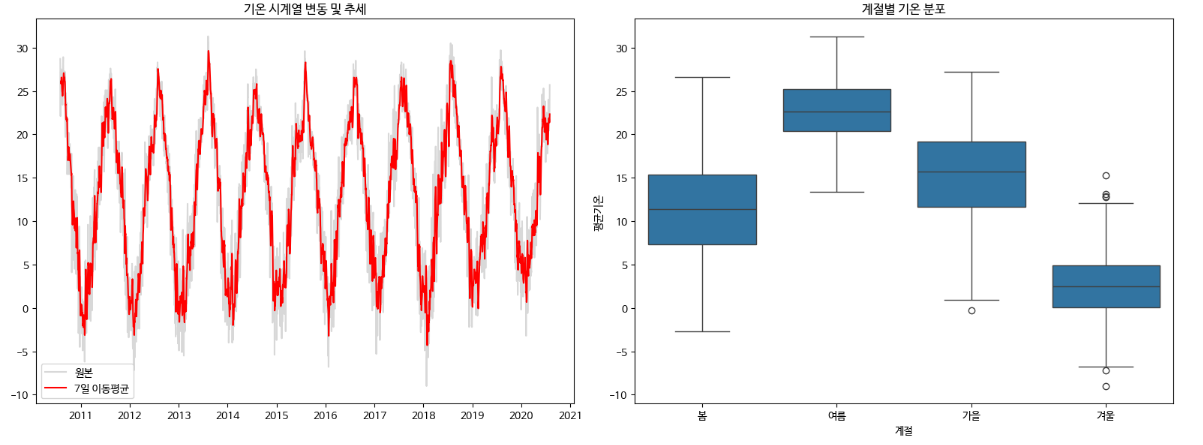

  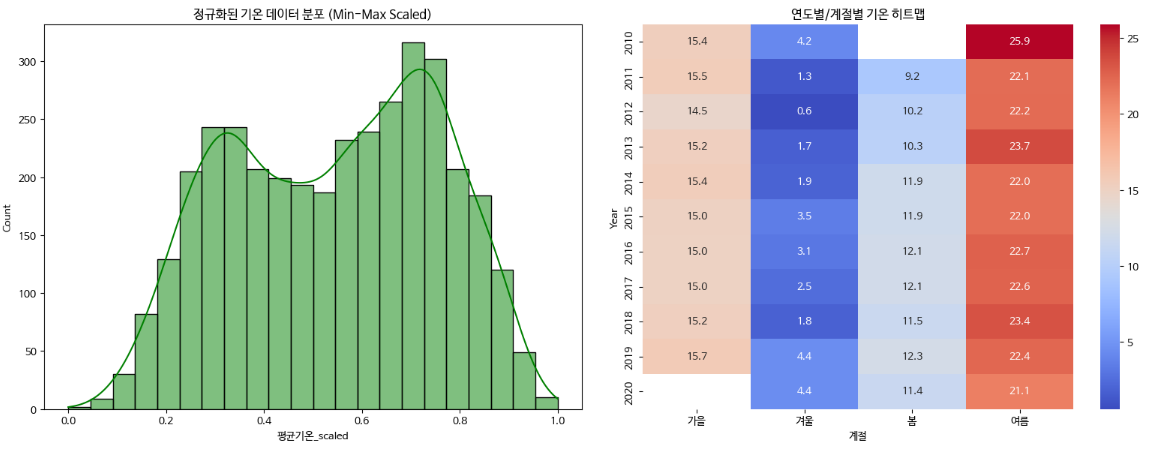



In [52]:
# 1. 환경 설정 및 한글 폰트 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import matplotlib.font_manager as fm

def setup_environment(): # 5주차 matplotlib 실습 파일 참고
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 파일 존재 여부 확인 및 설치
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 폰트 추가 (문제의 원인 해결)
    # FontProperties 대신 font_manager.fontManager.addfont를 사용.
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    # 'NanumBarunGothic'은 나눔폰트 파일의 실제 이름입니다.
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료")

In [53]:
# 2. 데이터 정규화(Min-Max Scaling)
def min_max_scale(series):
    result = (series - series.min()) / (series.max() - series.min())
    return result

In [54]:
# 3. 데이터 로드 및 전처리 (시계열 핸들링)
def load_and_preprocess():
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
    df = pd.read_csv(url, encoding='CP949')

    # to_datetime을 이용한 날짜형 데이터로의 변환
    df['일시'] = pd.to_datetime(df['일시'])

    # DatetimeIndex를 이용한 날짜 정보 추출
    df['Year'] = pd.DatetimeIndex(df['일시']).year
    df['Month'] = pd.DatetimeIndex(df['일시']).month

    # 시계열 인덱스 설정
    df.set_index('일시', inplace=True)

    # 결측치 선형 보간 및 정규화
    df['평균기온'] = df['평균기온'].interpolate(method='linear')
    df['평균기온_scaled'] = min_max_scale(df['평균기온'])

    return df

In [55]:
# 4. 시계열 분석
def perform_time_series_analysis(df):
  # 7일 이동 평균 추세선 생성
    df['7일 이동평균'] = df['평균기온'].rolling(window=7).mean()
    return df

In [56]:
# 5. 데이터 재구조화
def restructure_data(df):
    # 계절 매핑
    # 3월 부터 시작한 이유: 기상학적인 계절의 시작점(3월)을 기준으로 삼아 분석 결과와 그래프를 더 직관적으로 보여주기 위함(AI에게 질문)
    season_map = {3:'봄', 4:'봄', 5:'봄', 6:'여름', 7:'여름', 8:'여름',
                  9:'가을', 10:'가을', 11:'가을', 12:'겨울', 1:'겨울', 2:'겨울'}
    df['계절'] = df['Month'].map(season_map)

    # 계절 순서 리스트
    # 판다스의 기본 정렬(가나다순)이 이미지와 일치하지만, 실습에서 배운 reindex를 활용해 순서를 명시적으로 제어함.
    ordered_seasons = ['가을', '겨울', '봄', '여름']

    # groupby를 활용한 계절별 통계
    seasonal_stats = df.groupby('계절')[['평균기온', '평균풍속']].mean(numeric_only=True)
    seasonal_stats = seasonal_stats.reindex(ordered_seasons) # 순서 정렬

    # pivot_table을 활용한 연도별 요약
    yearly_pivot = df.pivot_table(index='Year', columns='계절', values='평균기온', aggfunc='mean')
    yearly_pivot = yearly_pivot.reindex(columns=ordered_seasons) # 컬럼 정렬

    return df, seasonal_stats, yearly_pivot

In [57]:
# 6. 데이터 분석 그래프 시각화
def visualize_results(df, yearly_pivot):
    plt.figure(figsize=(16, 12))

    # (1) 기온 시계열 변동 및 추세
    plt.subplot(2, 2, 1)
    plt.plot(df.index, df['평균기온'], color='lightgray', label='원본')
    plt.plot(df.index, df['7일 이동평균'], color='red', label='7일 이동평균')
    plt.title('기온 시계열 변동 및 추세')
    plt.legend(loc='lower left') # loc='lower left' : 범례 위치 지정

    # (2) 계절별 기온 분포
    plt.subplot(2, 2, 2)
    ordered_seasons = ['봄', '여름', '가을', '겨울']
    sns.boxplot(data=df, x='계절', y='평균기온', order=ordered_seasons, color='steelblue')
    plt.title('계절별 기온 분포')

    # (3) 정규화된 기온 데이터 분포
    plt.subplot(2, 2, 3)
    sns.histplot(df['평균기온_scaled'], kde=True, color='green')
    plt.title('정규화된 기온 데이터 분포 (Min-Max Scaled)')

    # (4) 연도별/계절별 기온 히트맵
    plt.subplot(2, 2, 4)
    sns.heatmap(yearly_pivot, cmap='coolwarm', annot=True, fmt='.1f') # cmap: 파라미터를 사용하여 그래프의 색상 테마
    plt.title('연도별/계절별 기온 히트맵')

    plt.tight_layout() # plt.subplot()을 사용하여 한 화면에 여러 그래프를 그릴 때, 겹침 방지 및 자동 간격 조정에 사용
    plt.show()

In [58]:
# 7. 엑셀 내보내기
def save_to_excel(df, seasonal_stats, yearly_pivot):
    # pd.ExcelWriter 활용 시트별 저장
    file_path = "weather_analysis_report.xlsx"
    with pd.ExcelWriter(file_path) as writer:
        df.to_excel(writer, sheet_name="전처리 데이터")
        seasonal_stats.to_excel(writer, sheet_name="계절별 통계")
        yearly_pivot.to_excel(writer, sheet_name="연도별 피벗 테이블")
    print(f"✅ 분석 결과가 '{file_path}'로 저장되었습니다.")

✅ 한글 폰트 설정 완료


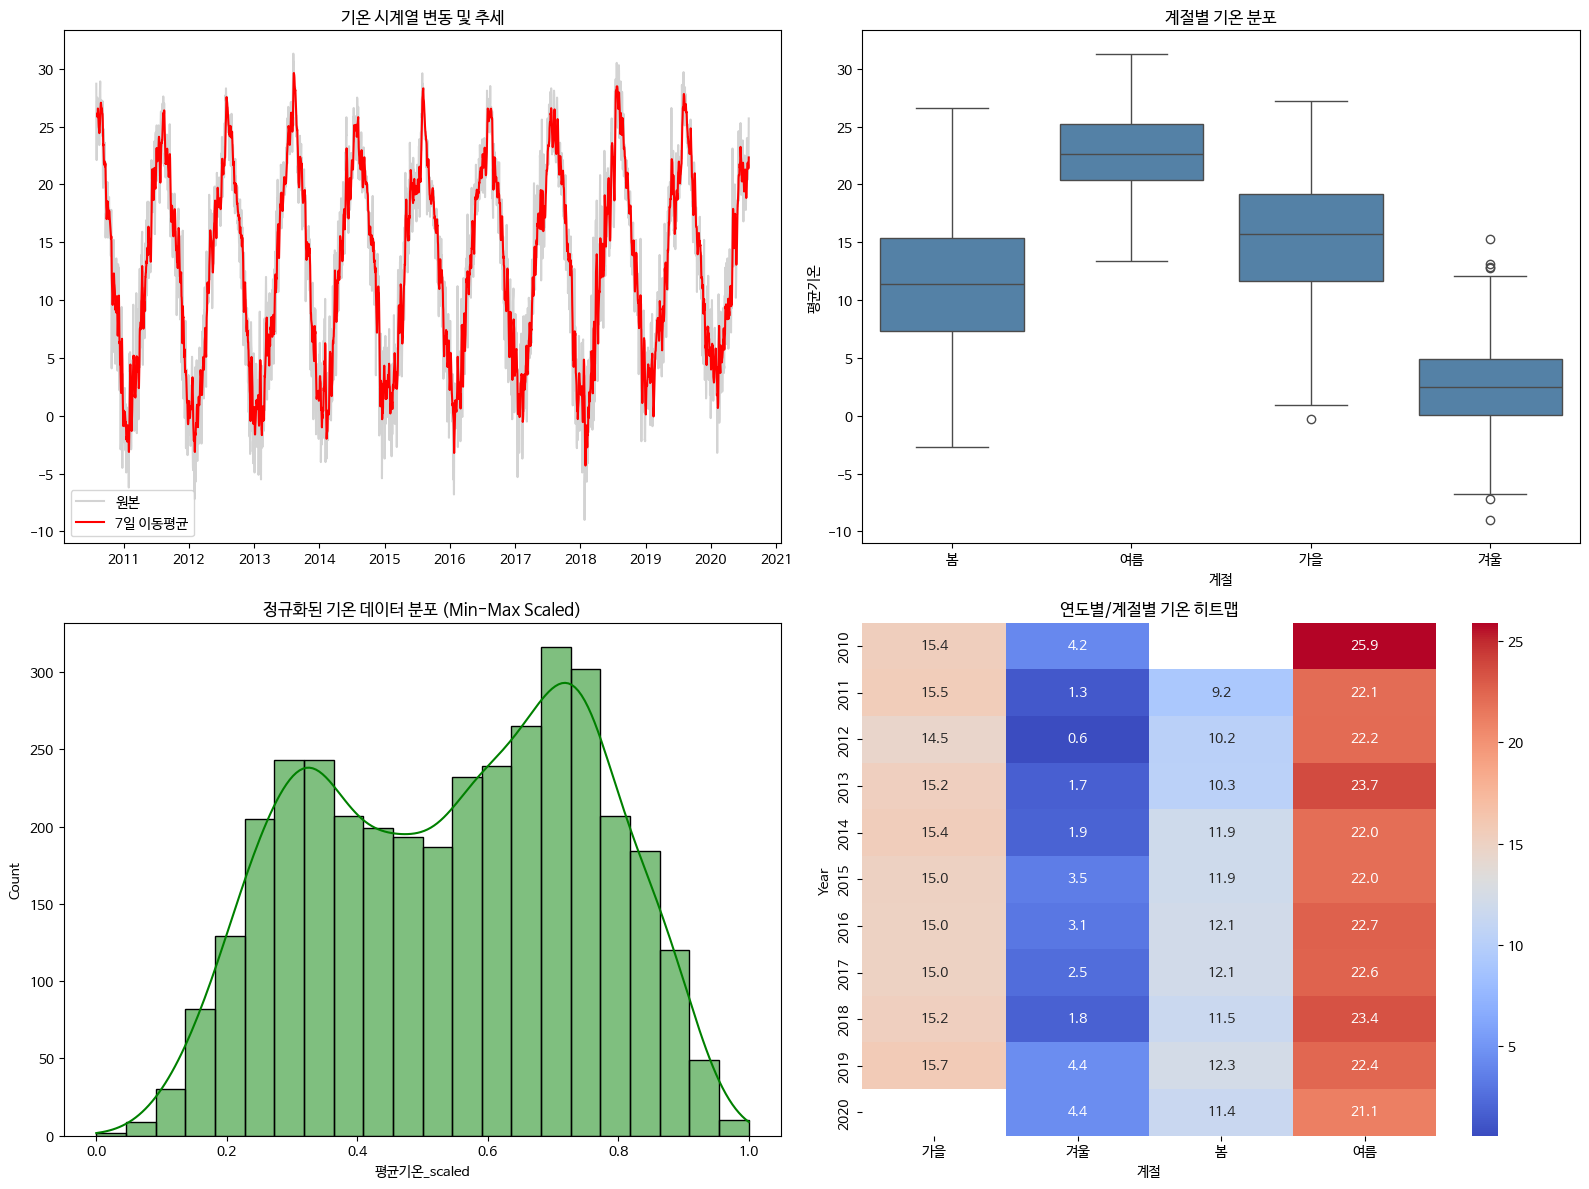

✅ 분석 결과가 'weather_analysis_report.xlsx'로 저장되었습니다.


In [59]:
# 8. 메인 제어 함수
def main():
    # 1. 환경 설정 및 한글 폰트 설정
    setup_environment()

    # 2. 데이터 로드 및 전처리
    df = load_and_preprocess()

    # 3. 시계열 분석 (7일 이동 평균)
    df = perform_time_series_analysis(df)

    # 4. 데이터 재구조화
    df, seasonal_stats, yearly_pivot = restructure_data(df)

    # 5. 데이터 분석 그래프 시각화
    visualize_results(df, yearly_pivot)

    # 6. 엑셀 내보내기
    save_to_excel(df, seasonal_stats, yearly_pivot)

# 프로그램 시작점
if __name__ == "__main__":
    main()